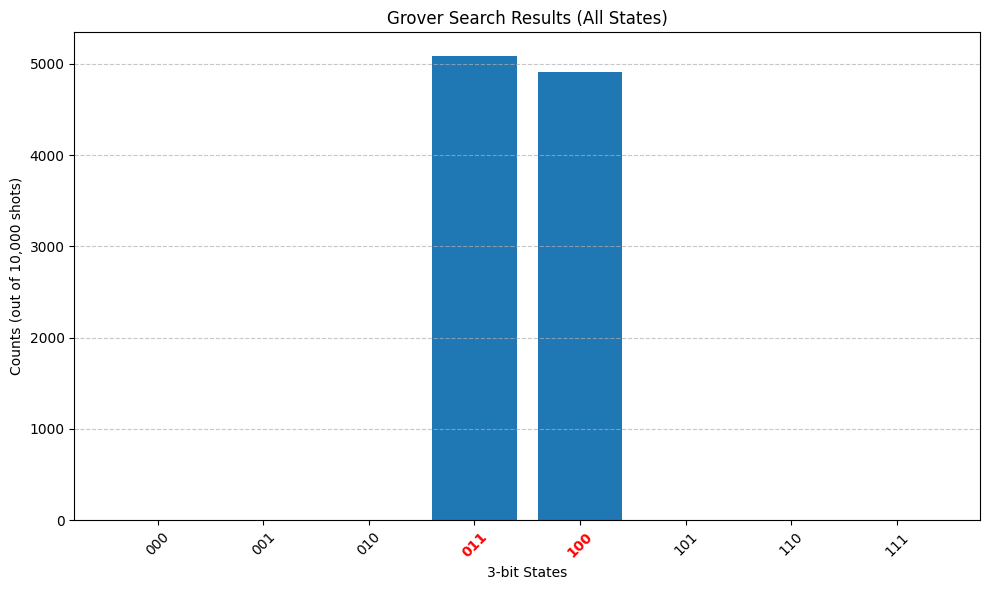

Measurement counts (all states): {'000': 0, '001': 0, '010': 0, '011': 5091, '100': 4909, '101': 0, '110': 0, '111': 0}


In [10]:
import math
import numpy as np
from qiskit import QuantumCircuit, transpile
from qiskit.circuit.library import GroverOperator, MCMT, ZGate
from qiskit_aer import Aer
import matplotlib.pyplot as plt

def build_grover_oracle(marked_states):
    """Build a Grover oracle for multiple marked states
    
    Parameters:
    marked_states (str or list): Marked states for oracle
    
    Returns:
    QuantumCircuit: Quantum circuit representing Grover oracle
    """
    if not isinstance(marked_states, list):
        marked_states = [marked_states]
    
    # Determine number of qubits needed
    num_qubits = len(marked_states[0])
    qc = QuantumCircuit(num_qubits, name="Oracle")
    
    # Mark each target state in the input list
    for target in marked_states:
        # Reverse target string to match Qiskit bit ordering
        rev_target = target[::-1]
        
        # Find indices of all '0' elements in bit-string
        zero_inds = [ind for ind in range(num_qubits) if rev_target[ind] == '0']
        
        # Apply X gates to flip '0's to '1's (open controls)
        qc.x(zero_inds)
        
        # Add multi-controlled Z-gate
        qc.append(MCMT(ZGate(), num_qubits-1, 1), range(num_qubits))
        
        # Flip back
        qc.x(zero_inds)
    
    return qc

def run_grover_search():
    """Main function to run Grover's search"""
    # Our marked states from the truth table
    solutions = ["011", "100"]
    
    # Step 1: Build the oracle
    oracle = build_grover_oracle(solutions)
    
    # Step 2: Create Grover operator
    grover_op = GroverOperator(oracle)
    
    # Step 3: Determine optimal number of iterations
    optimal_loops = math.floor(np.pi / (4 * math.asin(math.sqrt(len(solutions)/2**grover_op.num_qubits))))
    
    # Step 4: Build complete circuit
    qc = QuantumCircuit(grover_op.num_qubits)
    
    # Create superposition
    qc.h(range(grover_op.num_qubits))
    
    # Apply Grover operator optimal times
    qc.compose(grover_op.power(optimal_loops), inplace=True)
    
    # Measurement
    qc.measure_all()
    
    # Step 5: Run simulation
    simulator = Aer.get_backend('qasm_simulator')
    transpiled_qc = transpile(qc, simulator)
    result = simulator.run(transpiled_qc, shots=10000).result()
    counts = result.get_counts()
    
    # Generate all possible 3-bit states
    all_states = [f"{i:03b}" for i in range(8)]
    
    # Create ordered counts including zero counts
    ordered_counts = {state: counts.get(state, 0) for state in all_states}
    
    # Plot results with all states
    plt.figure(figsize=(10, 6))
    plt.bar(ordered_counts.keys(), ordered_counts.values())
    plt.xlabel('3-bit States')
    plt.ylabel('Counts (out of 10,000 shots)')
    plt.title('Grover Search Results (All States)')
    plt.xticks(rotation=45)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    
    # Highlight the solution states
    for solution in solutions:
        plt.gca().get_xticklabels()[int(solution, 2)].set_color('red')
        plt.gca().get_xticklabels()[int(solution, 2)].set_fontweight('bold')
    
    plt.tight_layout()
    plt.show()

    print("Measurement counts (all states):", ordered_counts)
    
    return ordered_counts

# Execute the algorithm
if __name__ == "__main__":
    results = run_grover_search()